In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests

#configuracion de graficos general,cuadricula blanca y tamaño
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, 'data')
FILE_PATH = os.path.join(DATA_DIR, 'avocado_raw.csv')

### Carga de datos

In [91]:
try:
    df_raw = pd.read_csv(FILE_PATH)
    print("archivo cargado")
except FileNotFoundError:
    print("no se encontro el csv")


archivo cargado


### estructura inicial

Estructura del dataset de avocados sacada de github https://github.com/erkansirin78/datasets/blob/master/avocado.csv

In [92]:
print("dimensiones")
print(f"filas {df_raw.shape[0]}")
print(f"columnas {df_raw.shape[1]}")

print("Primeras 5 filas ")
display(df_raw.head())
print("Ultimas 5 filas ")
display(df_raw.tail())

print("columnas")
print(df_raw.columns.tolist())


dimensiones
filas 18249
columnas 14
Primeras 5 filas 


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


Ultimas 5 filas 


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
18244,7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico
18248,11,2018-01-07,1.62,17489.58,2894.77,2356.13,224.53,12014.15,11988.14,26.01,0.0,organic,2018,WestTexNewMexico


columnas
['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']


Cada fila representa las ventas semanales en un area geografica, Durante la etapa de preprocesamiento se podria aplicar filtros para excluir areas geograficas especificas o centrarse en una sola


Se ve que la columna Total Volume equivale a la suma de la columna Total Bags y las tres columnas 4046, 4225 y 4770. Estos valores corresponden a las ventas por unidad de diferentes paltas siendo pequeña, mediana y grande, respectivamente, diferenciandose asi de las vendidas en bags o bolsas

La columna Unnamed: 0 parece ser inutil en el dataset ya que funciona como un indice y no aporta informacion relevante. 


La variable XLarge Bags muestra una alta frecuencia de valores en cero por lo que hay que analizarla para determinar si se trata de una ausencia real de ventas de ese formato o de una falta de registro en los datos

### analisis de datos

In [93]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


La columna Date es un object lo que puede complicar al modelo a interpretar correctamente la temporalidad de los datos, se debe estandarizar su formato para evitar confusiones del modelo,el resto de las variables presentan tipos de datos adecuados, el modelo no entiende que es 2015-12-27, lo mismo se debe realizar para la columnas type que es una categoria pues el modelo no entiende texto

### analisis de columnas extrañas

In [94]:
print("columna date")
print(f"tipo de dato: {df_raw['Date'].dtype}")
print(f"ejemplo: {df_raw['Date'].unique()[:5]}")

print("\ncolumna type")
print(df_raw['type'].value_counts())

print("\ncolumna region")
print(df_raw['region'].value_counts())

print("\ncolumna XLarge Bags")
print(df_raw['XLarge Bags'].value_counts(dropna=False))

print(f"\nregiones unicas {df_raw['region'].nunique()}\n")
print(df_raw['region'].unique())

columna date
tipo de dato: object
ejemplo: ['2015-12-27' '2015-12-20' '2015-12-13' '2015-12-06' '2015-11-29']

columna type
type
conventional    9126
organic         9123
Name: count, dtype: int64

columna region
region
Albany                 338
Atlanta                338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Columbus               338
DallasFtWorth          338
Denver                 338
Detroit                338
GrandRapids            338
GreatLakes             338
HarrisburgScranton     338
HartfordSpringfield    338
Houston                338
Indianapolis           338
Jacksonville           338
LasVegas               338
LosAngeles             338
Louisville             338
MiamiFtLauderdale      338
Midsouth               338
Nashville              338
NewOrleansMobile       338
NewYork                3

La columna XLarge Bags tiene una gran cantidad de valores en cero pero si tiene datos validos por lo que no es posible eliminarla, tampoco se ven errores de tipeoa que puedan provocar inconsistencias


En la columna Region hay que revisar la jerarquia para evitar la duplicidad de datos por que el dataset incluye ciudades individuales,estados y macro regiones

### metricas

In [95]:
display(df_raw.describe().round(2))

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00
mean,24.23,1.41,850644.01,293008.42,295154.57,22839.74,239639.20,182194.69,54338.09,3106.43,2016.15
std,15.48,0.40,3453545.36,1264989.08,1204120.40,107464.07,986242.40,746178.51,243965.96,17692.89,0.94
min,0.00,0.44,84.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2015.00
25%,10.00,1.10,10838.58,854.07,3008.78,0.00,5088.64,2849.42,127.47,0.00,2015.00
50%,24.00,1.37,107376.76,8645.30,29061.02,184.99,39743.83,26362.82,2647.71,0.00,2016.00
75%,38.00,1.66,432962.29,111020.20,150206.86,6243.42,110783.37,83337.67,22029.25,132.50,2017.00
max,52.00,3.25,62505646.52,22743616.17,20470572.61,2546439.11,19373134.37,13384586.80,5719096.61,551693.65,2018.00


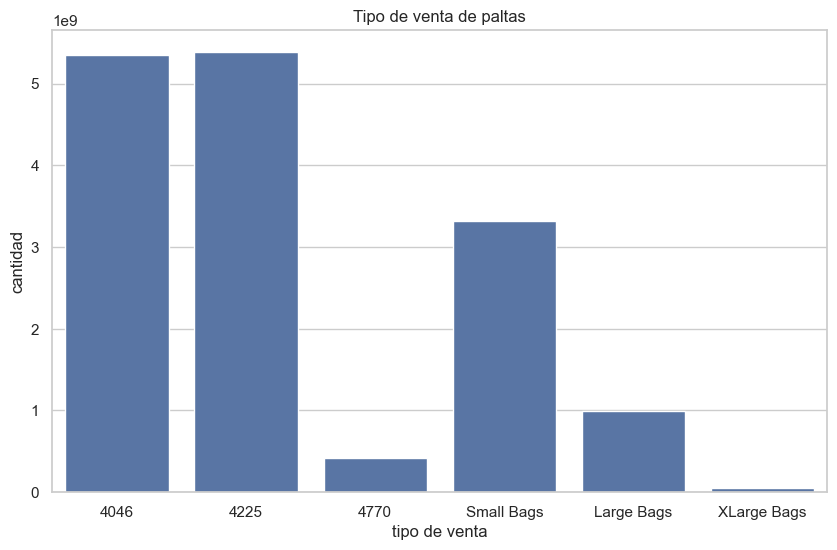

In [96]:
ventas_totales = df_raw[['4046', '4225', '4770', 'Small Bags', 'Large Bags', 'XLarge Bags']].sum()

plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_totales.index, y=ventas_totales.values)
plt.title('Tipo de venta de paltas')
plt.ylabel('cantidad')
plt.xlabel('tipo de venta')
plt.show()

El analisis usando count revela una consistencia total en el numero de filas, lo que confirma la ausencia de valores nulos en el dataset


En la distribucion de venta se ve otra vez que XLarge Bags si contiene valores distintos de cero pero su relevancia es poca por que el promedio de ventas de esta categoria es de 3,106.43 unidades siendo la opcion con menor demanda mientras que la preferencia de las ventas se inclina hacia 4225(medianas) con un promedio de 295,154.57 unidades seguido por 4046(chicas) con 293,008.42 unidades


Se observa una tendencia pues el volumen total de ventas por unidades individuales como la 4046 y 4225 supera significativamente a las ventas realizadas en formato de bolsas(Bags) y los consumidores que compran las bags optan predominantemente por Small Bag

Para evitar confusiones  cambiare las columnas de las paltas chicas,medianas y grandes a nombres mas intuitivos

### graficos

precio promedio por fecha

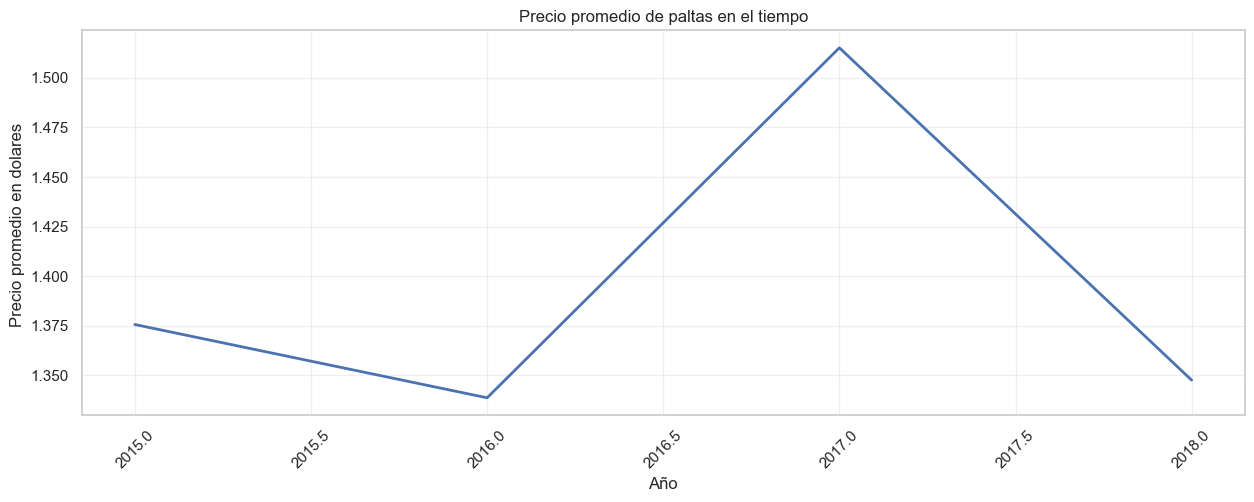

In [97]:
# Agrupa por fecha y hacer promedio de todas las regiones
df_tiempo = df_raw.groupby('year')['AveragePrice'].mean().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(df_tiempo['year'], df_tiempo['AveragePrice'], linewidth=2)
plt.title('Precio promedio de paltas en el tiempo')
plt.ylabel('Precio promedio en dolares ')
plt.xlabel('Año')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


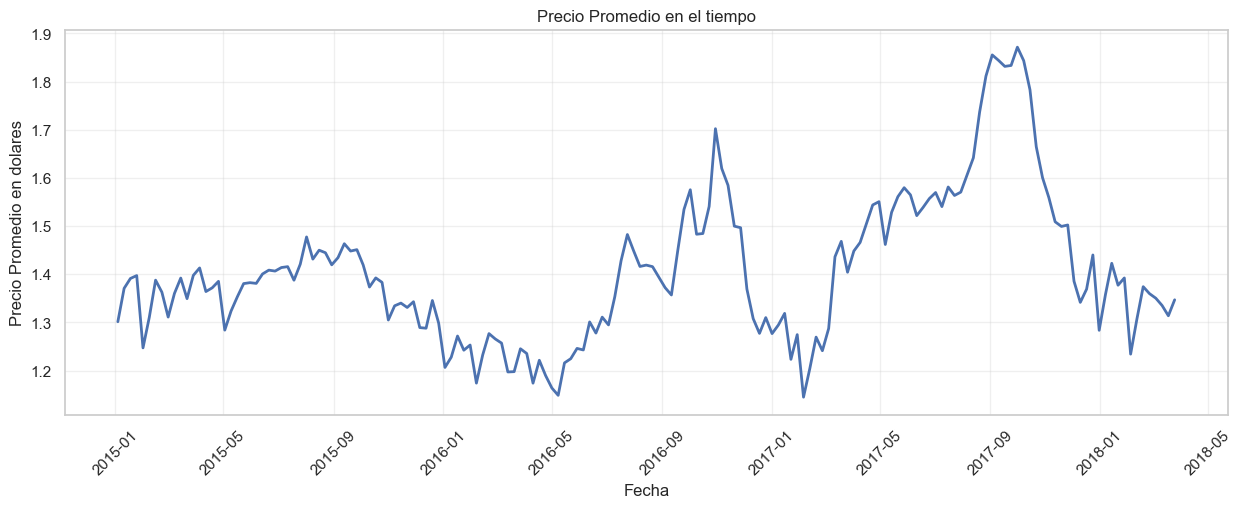

In [98]:
#convertir date a datatime
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Agrupa por fecha y hacer promedio de todas las regiones
df_tiempo = df_raw.groupby('Date')['AveragePrice'].mean().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(df_tiempo['Date'], df_tiempo['AveragePrice'], linewidth=2)
plt.title('Precio Promedio en el tiempo')
plt.ylabel('Precio Promedio en dolares')
plt.xlabel('Fecha')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

El precio promedio se disparo levemente entre la mitad de 2016 y 2017 para luego bajar y volver a la normalidad y luego se volvio a disparar hasta llegar a un pico de casi 1.9 dolares

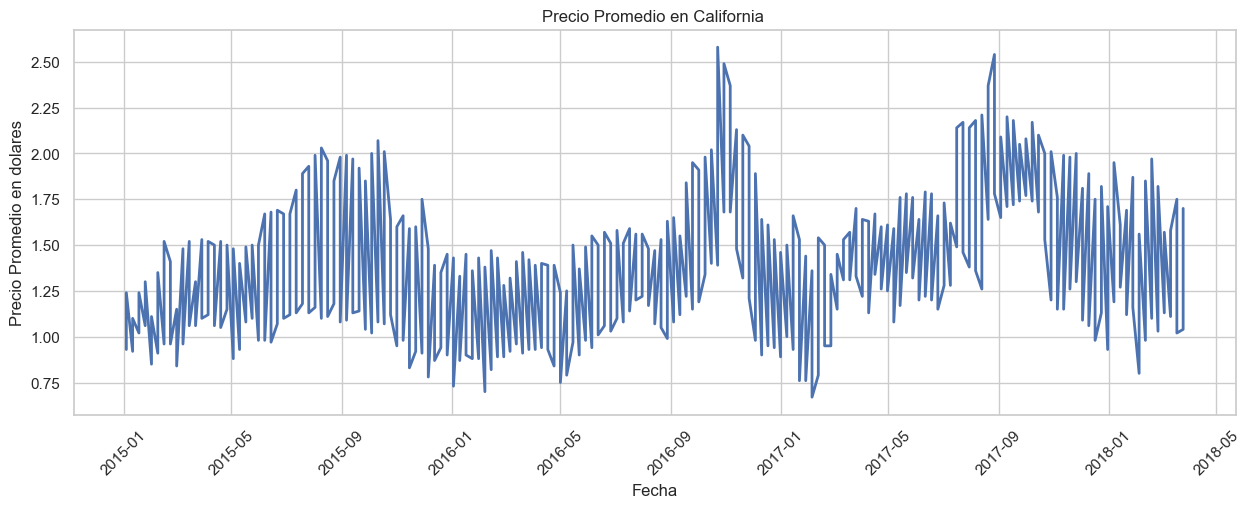

In [99]:
df_california = df_raw[df_raw['region'] == 'California']
df_california = df_california.sort_values('Date')

plt.figure(figsize=(15, 5))
plt.plot(pd.to_datetime(df_california['Date']), df_california['AveragePrice'], linewidth=2)
plt.title('Precio Promedio en California ')
plt.ylabel('Precio Promedio en dolares')
plt.xlabel('Fecha')
plt.xticks(rotation=45)
plt.show()

El precio promedio el california es similar al general pero con muchos picos y bajadas, parece ser mas erratico

### Buscar outliders en valores numericos

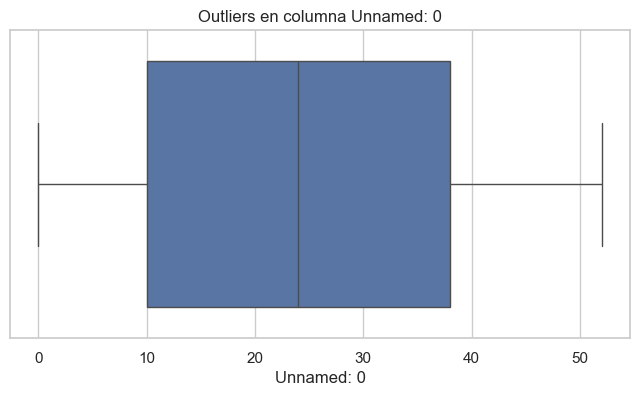

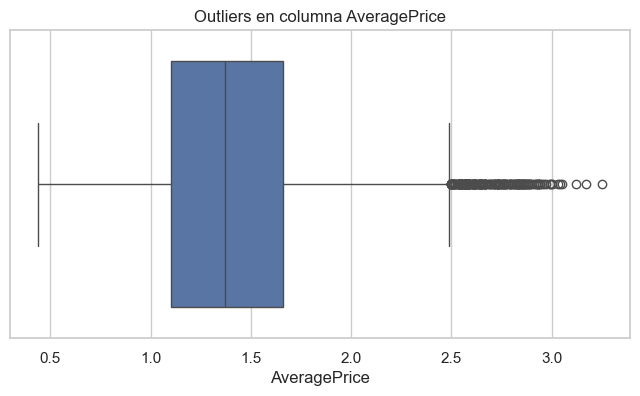

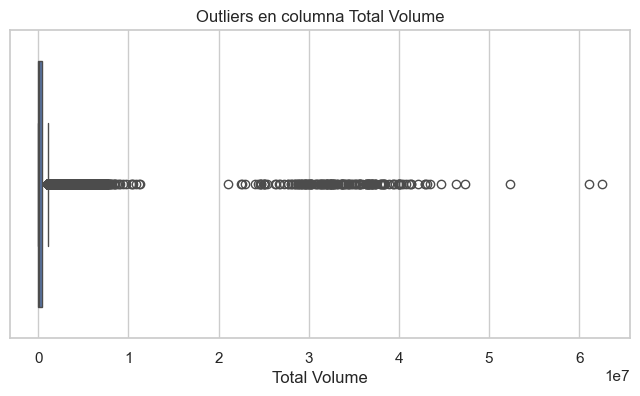

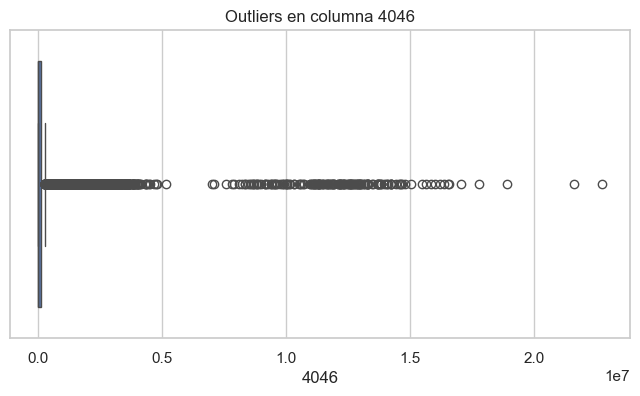

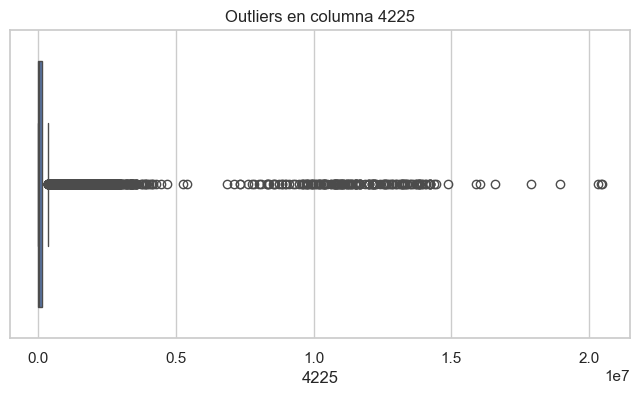

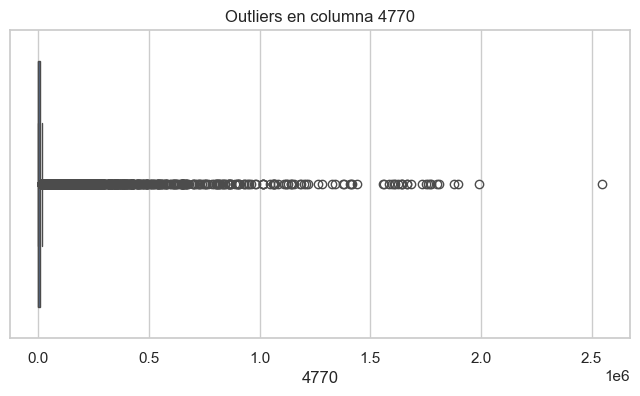

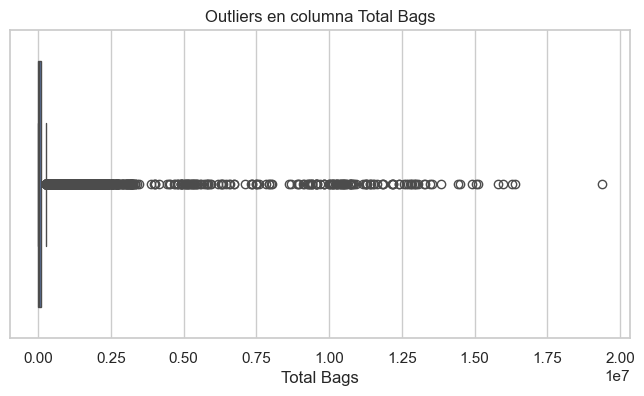

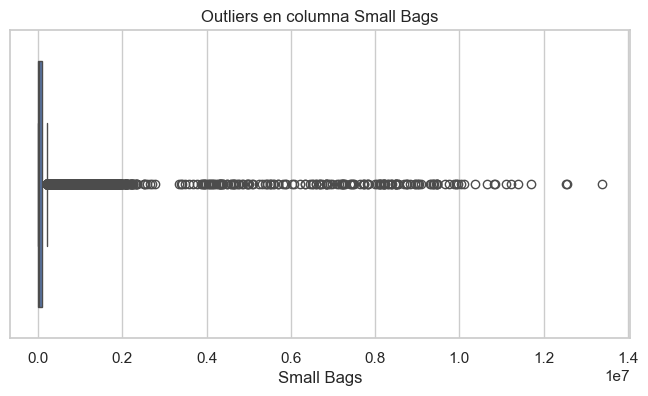

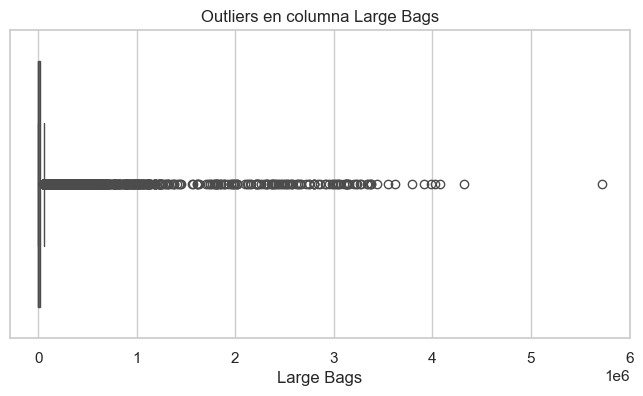

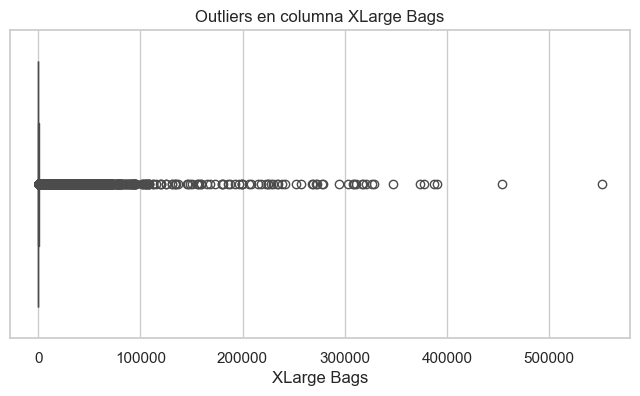

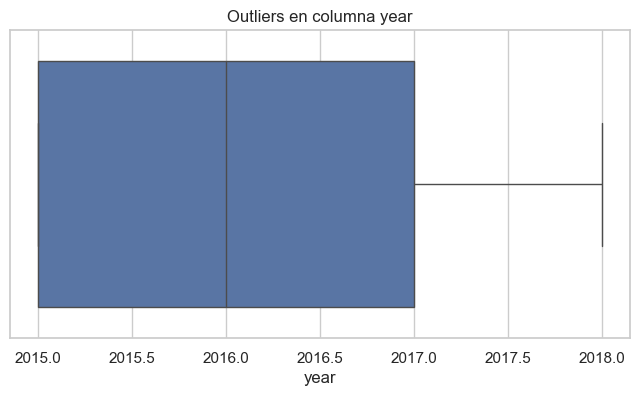

In [100]:
columnas_numericas = df_raw.select_dtypes(include=['float64', 'int64']).columns

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_raw[col])
    plt.title(f'Outliers en columna {col}')
    plt.show()

Las columnas tienen una presencia considerable de outliers pero como se va a usar XGBoost para la prediccion de la demanda no se requiere un tratamiento  de estos valores por que usa arboles de decision y eso lo hace robusto ante datos anomalos

### Buscar nulos

In [101]:
print(df_raw.isnull().sum())

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


Se confirma que no hay datos nulos en ninguna columna

### Buscar duplicados

In [102]:
print(f"Filas duplicadas: {df_raw.duplicated().sum()}")
#eliminarlas si hay
#df_raw = df_raw.drop_duplicates()

Filas duplicadas: 0


No hay filas que sean exactamente iguales

### Agrupacion por region

In [103]:
# agrupar y sumar
analisis_regional = df_raw.groupby('region')[['Total Volume', 'Total Bags']].sum()

# ordenar de mayor a menor 
analisis_regional = analisis_regional.sort_values(by='Total Volume', ascending=False)
print(analisis_regional)

                     Total Volume    Total Bags
region                                         
TotalUS              5.864740e+09  1.638601e+09
West                 1.086779e+09  3.670736e+08
California           1.028982e+09  2.466822e+08
SouthCentral         1.011280e+09  2.333924e+08
Northeast            7.132809e+08  1.969884e+08
Southeast            6.152384e+08  1.815276e+08
GreatLakes           5.896425e+08  1.785756e+08
Midsouth             5.083494e+08  1.565136e+08
LosAngeles           5.078965e+08  1.682645e+08
Plains               3.111885e+08  7.784720e+07
NewYork              2.407341e+08  6.799416e+07
DallasFtWorth        2.084193e+08  4.646975e+07
Houston              2.031679e+08  5.021506e+07
PhoenixTucson        1.956433e+08  3.890824e+07
WestTexNewMexico     1.445218e+08  3.529652e+07
Denver               1.389025e+08  5.895701e+07
SanFrancisco         1.358302e+08  1.489092e+07
BaltimoreWashington  1.347139e+08  3.530615e+07
Chicago              1.337023e+08  1.686

In [104]:
# valor total de TotalUS
valor_total_us = df_raw[df_raw['region'] == 'TotalUS']['Total Volume'].sum()

# Suma de todo lo demas
suma_resto = df_raw[df_raw['region'] != 'TotalUS']['Total Volume'].sum()

print(f"Valor TotalUS: {valor_total_us:,.0f}")
print(f"Suma del Resto: {suma_resto:,.0f}")

Valor TotalUS: 5,864,740,182
Suma del Resto: 9,658,662,412


Se ve una incongruencia por que aunque el valor de TotalUS es masivo la suma simple del resto de las filas da un resultado superior lo cual es inconsistente


Esto confirma la existencia de una superposicion jerarquica en la columna region pues al sumar todos los registros hay duplicidad de datos ya que parece ser que las ventas de ciudades individuales como Los Angeles o San Francisco estan ya integradas en las cifras de sus estados como California y a su vez en las de las macro regiones como West y por eso la suma global es mayor al valor de TotalUS debido a un conteo multiple


Para evitar que el modelo reciba datos duplicados de ventasimportante filtrar el dataset y trabajar unicamente con un nivel de jerarquia


Para que el preprocesamiento garantize buenos datos al modelo primero se aplicara un filtro en la columna region para conservar solo los registros a nivel de ciudad eliminando las macro regiones y el agregado nacional para evitar duplicaciones, luego se realizara la conversion de la columna Date al formato datetime para una buenainterpretacion temporal  del modelo y se va a renombrar las columnas con los codigos  4046, 4225 y 4770 por nombres descriptivas como pequeño, mediano y grande para mejorar la interpretabilidad del set de datos y se eliminara la columna Unnamed: 0 al ser un indice inutil que no aporta nada

### dataset ya preprocesado en el process_data.py

In [105]:
FILE_PATH = os.path.join(DATA_DIR, 'avocado_processed.csv')
df_raw = pd.read_csv(FILE_PATH)
print(df_raw.columns.tolist())

['Date', 'AVGPrice', 'Volumen', 'Palta_pequeña', 'Palta_mediana', 'Palta_grande', 'Total Bags', 'S_Bags', 'L_Bags', 'XL_Bags', 'type', 'year', 'region']


In [106]:
print("Primeras 5 filas ")
display(df_raw.head())

Primeras 5 filas 


,Date,AVGPrice,Volumen,Palta_pequeña,Palta_mediana,Palta_grande,Total Bags,S_Bags,L_Bags,XL_Bags,type,year,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,2015,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,2015,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,2015,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,2015,BaltimoreWashington


In [107]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14196 entries, 0 to 14195
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           14196 non-null  object 
 1   AVGPrice       14196 non-null  float64
 2   Volumen        14196 non-null  float64
 3   Palta_pequeña  14196 non-null  float64
 4   Palta_mediana  14196 non-null  float64
 5   Palta_grande   14196 non-null  float64
 6   Total Bags     14196 non-null  float64
 7   S_Bags         14196 non-null  float64
 8   L_Bags         14196 non-null  float64
 9   XL_Bags        14196 non-null  float64
 10  type           14196 non-null  object 
 11  year           14196 non-null  int64  
 12  region         14196 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 1.4+ MB


In [108]:
print(df_raw['region'].value_counts())

region
Albany                 338
Atlanta                338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Columbus               338
DallasFtWorth          338
Denver                 338
Detroit                338
GrandRapids            338
HarrisburgScranton     338
HartfordSpringfield    338
Houston                338
Indianapolis           338
Jacksonville           338
LasVegas               338
LosAngeles             338
Louisville             338
MiamiFtLauderdale      338
Nashville              338
NewOrleansMobile       338
NewYork                338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Portland               338
RaleighGreensboro      338
RichmondNorfolk        338
Roanoke                338
Sacramento             338
SanDiego               338
SanFrancisco         

Apesar de que en el preprocesamiento use df['Date'] = pd.to_datetime(df['Date']) para estandarizar la columna Date sigue apareciendo como object en el nuevo csv, al investigar la explicacion fue que al guardar en csv el cambio que realizo datetime no se guarda, tengo que realizarlo en el mismo codigo del modelo, los demas cambios parecen haberse aplicado correctamente, lo mismo se debe realizar para las columna de categoria type pues el modelo no entiende texto

En el mismo codigo del modelo convertir datos convertir datos complejos como la fecha y categorias en señales numéricas simples para XGBoost